# *Statistics*  — Studi Kasus Data Polutan Bangkalan
### Informasi Dataset
| **Informasi**                | **Keterangan**                                             |
| ---------------------------- | ---------------------------------------------------------- |
| **Nama Dataset**             | Data Polutan Bangkalan (Time Series)                       |
| **Lokasi**                   | Kabupaten Bangkalan, Jawa Timur                            |
| **Periode Data**             | 31 Agustus 2025 – 29 Agustus 2026                          |
| **Jumlah Baris (Row Count)** | 328 baris (data berdasarkan tanggal)                       |
| **Jumlah Fitur/Kolom**       | 6 kolom (1 kolom tanggal + 5 fitur polutan)                |
| **Kolom Tanggal**            | `date`                                                     |
| **Daftar Fitur Polutan**     | `no2`, `co`, `so2`, `hcho`, `ch4`                          |
| **Jumlah Fitur Polutan**     | 5 fitur                                                    |
| **Tipe Data Kolom Tanggal**  | Date/Datetime                                              |
| **Tipe Data Fitur Polutan**  | Numerik (`Double` / `Float`)                               |
| **Jenis Dataset**            | Time Series (Deret Waktu)                                  |

Dataset yang digunakan adalah data polutan udara harian di Kabupaten Bangkalan periode
31 Agustus 2025 – 29 Agustus 2026, terdiri dari 5 fitur (kolom):

| Kolom | Nama Polutan | Satuan |
|---|---|---|
| `no2`  | Nitrogen Dioksida     | mol/m² |
| `co`   | Karbon Monoksida      | mol/m² |
| `so2`  | Sulfur Dioksida       | mol/m² |
| `hcho` | Formaldehida          | mol/m² |
| `ch4`  | Metana                | ppb    |

Data ini adalah hasil pemantauan satelit (mirip Sentinel-5P), sehingga wajar jika ada
beberapa tanggal yang datanya hilang (missing) akibat tutupan awan atau kendala akuisisi citra.


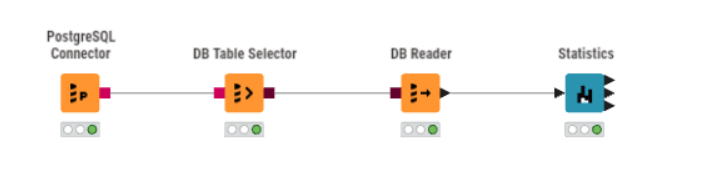

## 1. Import Library & Memuat Data

Kita akan menggunakan:
- `pandas` → memuat & mengolah data tabular
- `numpy` → operasi numerik & array
- `scipy.stats` → fungsi statistik lanjutan (skewness, kurtosis)
- `matplotlib` → membuat histogram (setara *Nominal Histogram Table* pada KNIME)


In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()
nama_file = list(uploaded.keys())[0]
print(f"File berhasil di-upload: {nama_file}")

# Deteksi otomatis apakah file berformat .csv atau .xlsx
if nama_file.lower().endswith('.xlsx'):
    df = pd.read_excel(nama_file)
else:
    df = pd.read_csv(nama_file)

df['date'] = pd.to_datetime(df['date'])

print("Dimensi data:", df.shape)
df.head(10)

Saving data_polutan_bangkalan.csv to data_polutan_bangkalan (1).csv
File berhasil di-upload: data_polutan_bangkalan (1).csv
Dimensi data: (328, 6)


,date,no2,co,so2,hcho,ch4
0,2025-08-31,1.21886e-05,0.0259366,-1.7806e-05,0.000122764,NaN
1,2025-09-01,1.42729e-05,0.0268811,5.16868e-05,6.87477e-05,NaN
2,2025-09-02,1.3803e-05,0.0244888,-4.62924e-05,3.62969e-05,NaN
3,2025-09-03,1.52928e-05,0.0243091,3.29605e-05,7.6519e-05,"1,887"
4,2025-09-04,1.80922e-05,0.0274189,1.52775e-05,0.00010283,"1,843.32"
5,2025-09-05,1.82711e-05,0.0288486,3.17722e-06,0.000136781,"1,845.15"
6,2025-09-06,2.73179e-05,0.0301687,0.000118344,0.000185738,NaN
7,2025-09-07,1.94827e-05,0.0289516,-6.52402e-05,9.85246e-05,NaN
8,2025-09-08,2.19308e-05,0.0333932,-5.64167e-06,0.000152376,NaN
9,2025-09-09,2.84709e-05,0.0259859,-5.74305e-05,7.43506e-05,NaN


> **Catatan:** Jalankan cell di atas, lalu klik tombol **"Choose Files"** yang muncul dan pilih
> file `data_polutan_bangkalan.csv` (atau `.xlsx`) yang sudah kamu download. Notebook ini otomatis
> mendeteksi apakah file yang di-upload berformat CSV atau Excel.


In [25]:
# info tipe data & jumlah nilai kosong per kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    328 non-null    datetime64[ns]
 1   no2     282 non-null    float64       
 2   co      274 non-null    float64       
 3   so2     311 non-null    float64       
 4   hcho    322 non-null    float64       
 5   ch4     73 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 15.5 KB


## 2. Apa itu Node *Statistics* di KNIME?

Node Statistics menghitung ringkasan (*summary statistics*) untuk setiap kolom numerik dalam dataset. Hasilnya ditampilkan dalam Statistics Table, yang berisi:

`Min`, `Max`, `Mean`, `Std. deviation`, `Variance`, `Skewness`, `Kurtosis`, `Overall sum`,
`No. missing`, `No. NaNs`, `No. +∞s`, `No. -∞s`, `Median`, `Row count`, dan `Histogram`.

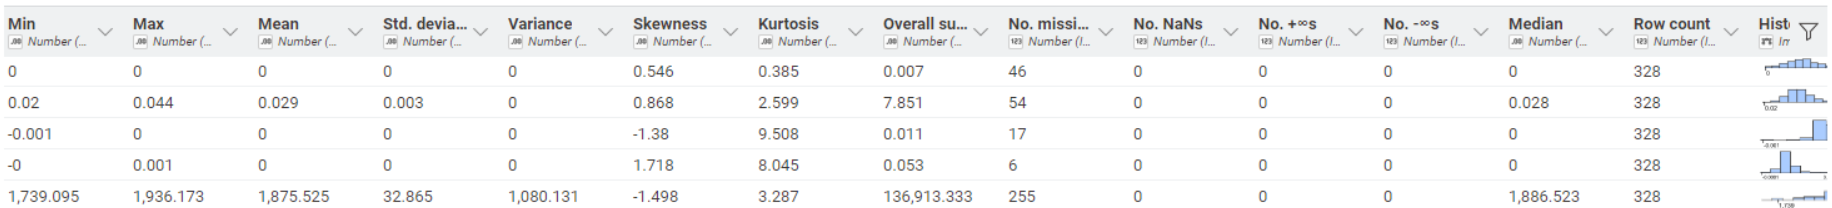

## 3.1 Row Count (Jumlah Baris)

Definisi: Jumlah total baris/observasi dalam kolom tersebut, termasuk baris yang nilainya
kosong (missing/NaN). `Row count = 328`,
artinya total ada 328 baris tanggal dalam dataset gabungan.

**Rumus:**
$$
N_{row} = \text{banyaknya baris dalam tabel}
$$

hitungan (count) sederhana atas seluruh baris data.


In [26]:
row_count = len(df)
print(f"Row count (jumlah total baris pada dataset) = {row_count}")

# row count harus sama untuk semua kolom karena dihitung dari jumlah baris tabel
for col in ['no2', 'co', 'so2', 'hcho', 'ch4']:
    print(f"Row count kolom '{col}': {len(df[col])}")


Row count (jumlah total baris pada dataset) = 328
Row count kolom 'no2': 328
Row count kolom 'co': 328
Row count kolom 'so2': 328
Row count kolom 'hcho': 328
Row count kolom 'ch4': 328


## 3.2 No. Missing & No. NaNs (Jumlah Nilai Hilang)

KNIME membedakan dua jenis nilai kosong:

- No. missing: total sel yang tidak berisi nilai — mencakup nilai yang memang tidak pernah
  terisi (misal karena baris tidak memiliki data untuk kolom itu) dan nilai yang berupa `NaN`.
- No. NaNs: subset khusus dari nilai hilang di atas yang secara eksplisit bertipe
  *Not-a-Number* (hasil dari operasi matematika tidak valid, misalnya `0/0`).

Karena dataset kita adalah hasil outer-join dari 5 file time series yang tanggalnya tidak selalu
sama, kolom yang tidak mempunyai data pada suatu tanggal akan terisi `NaN` oleh pandas — sehingga
pada dataset ini `No. missing` = `No. NaNs`.

**Rumus:**
$$
\text{No. missing} = \sum_{i=1}^{N_{row}} \mathbb{1}[\,x_i \text{ kosong / NaN}\,]
$$

di mana $\mathbb{1}[\cdot]$ adalah fungsi indikator (bernilai 1 jika kondisi benar, 0 jika salah).


In [27]:
print("No. missing (termasuk NaN) per kolom ")
missing_count = df[['no2','co','so2','hcho','ch4']].isna().sum()
print(missing_count)

print("\n No. NaNs (eksplisit) per kolom ")
# Karena semua nilai kosong di dataset ini adalah hasil outer-join (NaN),
# No. NaNs = No. missing
nan_count = df[['no2','co','so2','hcho','ch4']].apply(lambda s: np.isnan(s).sum())
print(nan_count)

total_baris = len(df['ch4'])
jumlah_kosong = df['ch4'].isna().sum()
print(f"\nContoh manual kolom 'ch4': dari {total_baris} baris, "
      f"yang kosong = {jumlah_kosong} baris (karena file CH4 asli hanya punya "
      f"{total_baris - jumlah_kosong} baris data, sisanya tidak tercatat).")


No. missing (termasuk NaN) per kolom 
no2      46
co       54
so2      17
hcho      6
ch4     255
dtype: int64

 No. NaNs (eksplisit) per kolom 
no2      46
co       54
so2      17
hcho      6
ch4     255
dtype: int64

Contoh manual kolom 'ch4': dari 328 baris, yang kosong = 255 baris (karena file CH4 asli hanya punya 73 baris data, sisanya tidak tercatat).


## 3.3 No. +∞s & No. -∞s (Jumlah Nilai Tak Hingga)

Sel bernilai positive infinity (+∞) atau negative infinity (−∞) biasanya muncul akibat
pembagian dengan nol pada data numerik (misalnya `1/0 = +∞` atau `-1/0 = -∞`). Node Statistics
menghitung berapa banyak sel semacam ini pada tiap kolom.

**Rumus:**
$$
\text{No. } +\infty = \sum_{i=1}^{N_{row}} \mathbb{1}[\,x_i = +\infty\,]
\qquad
\text{No. } -\infty = \sum_{i=1}^{N_{row}} \mathbb{1}[\,x_i = -\infty\,]
$$

Pada data polutan kita, seluruh kolom menunjukkan `0` untuk kedua metrik ini — artinya data
pengukuran satelit tidak mengandung nilai tak hingga (data "bersih" dari sisi ini).


In [28]:
for col in ['no2','co','so2','hcho','ch4']:
    n_pos_inf = np.isposinf(df[col]).sum()
    n_neg_inf = np.isneginf(df[col]).sum()
    print(f"{col}: No. +inf = {n_pos_inf}, No. -inf = {n_neg_inf}")

no2: No. +inf = 0, No. -inf = 0
co: No. +inf = 0, No. -inf = 0
so2: No. +inf = 0, No. -inf = 0
hcho: No. +inf = 0, No. -inf = 0
ch4: No. +inf = 0, No. -inf = 0


## 3.4 Minimum & Maximum

Definisi: Nilai terkecil (`Min`) dan terbesar (`Max`) dari seluruh nilai valid (bukan NaN)
dalam suatu kolom.

**Rumus:**
$$
\text{Min} = \min\{x_1, x_2, \dots, x_n\} \qquad \text{Max} = \max\{x_1, x_2, \dots, x_n\}
$$

di mana $n$ adalah jumlah nilai valid (tidak termasuk yang missing/NaN).

### Contoh perhitungan manual (5 nilai pertama kolom `co`)


In [29]:
contoh_co = df['co'].dropna().head(5).tolist()
print("5 nilai pertama 'co':", contoh_co)

# Perhitungan manual (tanpa fungsi bawaan): bandingkan satu per satu
manual_min = contoh_co[0]
manual_max = contoh_co[0]
for v in contoh_co[1:]:
    if v < manual_min:
        manual_min = v
    if v > manual_max:
        manual_max = v
print(f"Min manual dari 5 nilai contoh = {manual_min}")
print(f"Max manual dari 5 nilai contoh = {manual_max}")

# Verifikasi dengan fungsi bawaan pada 5 nilai yang sama
print(f"Cek dengan min()/max() bawaan   = {min(contoh_co)} / {max(contoh_co)}")

5 nilai pertama 'co': [0.0259365929357175, 0.026881145151413, 0.0244888178730273, 0.0243090533691903, 0.0274189419782998]
Min manual dari 5 nilai contoh = 0.0243090533691903
Max manual dari 5 nilai contoh = 0.0274189419782998
Cek dengan min()/max() bawaan   = 0.0243090533691903 / 0.0274189419782998


In [30]:
# Sekarang hitung Min & Max untuk SELURUH data (328 baris, nilai valid saja)
print("Min & Max seluruh dataset (nilai valid saja)")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Min = {df[col].min():.6g}   Max = {df[col].max():.6g}")

Min & Max seluruh dataset (nilai valid saja)
no2: Min = 4.71696e-06   Max = 5.54211e-05
co: Min = 0.0204874   Max = 0.043943
so2: Min = -0.000902327   Max = 0.000421448
hcho: Min = -8.63589e-05   Max = 0.000680752
ch4: Min = 1739.1   Max = 1936.17


## 3.5 Mean (Rata-rata)

Definisi: Rata-rata aritmetika dari seluruh nilai valid.

**Rumus:**
$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

### Contoh perhitungan manual (5 nilai pertama kolom `co`)

$$
\bar{x} = \frac{0.025937 + 0.026881 + 0.024489 + 0.024309 + 0.027419}{5}
$$


In [31]:
contoh_co = df['co'].dropna().head(5).tolist()

# Perhitungan manual
jumlah = 0
for v in contoh_co:
    jumlah += v
n = len(contoh_co)
mean_manual = jumlah / n

print(f"Nilai       : {contoh_co}")
print(f"Jumlah (Σx) : {jumlah}")
print(f"n           : {n}")
print(f"Mean manual : {mean_manual}")

# Verifikasi dengan fungsi bawaan
print(f"Cek np.mean : {np.mean(contoh_co)}")


Nilai       : [0.0259365929357175, 0.026881145151413, 0.0244888178730273, 0.0243090533691903, 0.0274189419782998]
Jumlah (Σx) : 0.1290345513076479
n           : 5
Mean manual : 0.02580691026152958
Cek np.mean : 0.02580691026152958


In [32]:
# Mean untuk SELURUH dataset
print("Mean seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Mean = {df[col].mean():.6g}")

Mean seluruh dataset
no2: Mean = 2.48246e-05
co: Mean = 0.0286525
so2: Mean = 3.3773e-05
hcho: Mean = 0.000165661
ch4: Mean = 1875.53


## 3.6 Median

Definisi: Nilai tengah dari data yang sudah diurutkan. Median lebih tahan (*robust*)
terhadap nilai ekstrem (*outlier*) dibanding Mean.

**Rumus:**

$$
\text{Median} =
\begin{cases}
x_{\left(\frac{n+1}{2}\right)} & \text{jika } n \text{ ganjil} \\[6pt]
\dfrac{x_{(n/2)} + x_{(n/2+1)}}{2} & \text{jika } n \text{ genap}
\end{cases}
$$

di mana $x_{(k)}$ adalah nilai ke-$k$ setelah data diurutkan naik (*ascending*).

### Contoh perhitungan manual (5 nilai pertama kolom `co`, n = 5 → ganjil)


In [33]:
contoh_co = df['co'].dropna().head(5).tolist()
print("Data asli  :", contoh_co)

data_urut = sorted(contoh_co)
print("Data urut  :", data_urut)

n = len(data_urut)
if n % 2 == 1:
    posisi_tengah = (n + 1) // 2   # posisi ke-3 dari 5 data
    median_manual = data_urut[posisi_tengah - 1]  # index dimulai dari 0
    print(f"n = {n} (ganjil) -> posisi tengah = ke-{posisi_tengah}")
else:
    kiri = data_urut[n//2 - 1]
    kanan = data_urut[n//2]
    median_manual = (kiri + kanan) / 2
    print(f"n = {n} (genap) -> rata-rata dua nilai tengah: {kiri} & {kanan}")

print(f"Median manual = {median_manual}")
print(f"Cek np.median = {np.median(contoh_co)}")

Data asli  : [0.0259365929357175, 0.026881145151413, 0.0244888178730273, 0.0243090533691903, 0.0274189419782998]
Data urut  : [0.0243090533691903, 0.0244888178730273, 0.0259365929357175, 0.026881145151413, 0.0274189419782998]
n = 5 (ganjil) -> posisi tengah = ke-3
Median manual = 0.0259365929357175
Cek np.median = 0.0259365929357175


In [34]:
# Median untuk SELURUH dataset
print("Median seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Median = {df[col].median():.6g}")

Median seluruh dataset
no2: Median = 2.40767e-05
co: Median = 0.0283222
so2: Median = 3.29605e-05
hcho: Median = 0.000157265
ch4: Median = 1886.52


## 3.7 Variance & Standard Deviation (Ragam & Simpangan Baku)

**Variance** mengukur seberapa jauh sebaran nilai dari rata-ratanya (dikuadratkan agar semua
selisih bernilai positif). **Standard deviation** adalah akar dari variance, sehingga satuannya
kembali sama dengan satuan data asli — lebih mudah diinterpretasikan.

KNIME (mengikuti kebanyakan tools statistik) menggunakan **sample variance** (pembagi $n-1$,
disebut juga koreksi Bessel) agar estimasi tidak bias terhadap populasi.

**Rumus Variance (sampel):**
$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2
$$

**Rumus Standard Deviation (sampel):**
$$
s = \sqrt{s^2} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}
$$

### Contoh perhitungan manual (5 nilai pertama kolom `co`)


In [35]:
contoh_co = df['co'].dropna().head(5).tolist()
n = len(contoh_co)
mean_manual = sum(contoh_co) / n
print(f"Data        : {contoh_co}")
print(f"Mean (x̄)    : {mean_manual}")

# Langkah 1: hitung selisih tiap nilai terhadap mean, lalu kuadratkan
kuadrat_selisih = [(v - mean_manual) ** 2 for v in contoh_co]
print(f"(x - x̄)^2 tiap nilai: {kuadrat_selisih}")

# Langkah 2: jumlahkan semua kuadrat selisih
jumlah_kuadrat = sum(kuadrat_selisih)
print(f"Σ(x - x̄)^2 = {jumlah_kuadrat}")

# Langkah 3: bagi dengan (n-1) -> variance sampel
variance_manual = jumlah_kuadrat / (n - 1)
print(f"Variance manual (dibagi n-1={n-1}) = {variance_manual}")

# Langkah 4: akar kuadrat dari variance -> standard deviation
std_manual = variance_manual ** 0.5
print(f"Std deviation manual = {std_manual}")

# Verifikasi dengan fungsi bawaan (ddof=1 supaya sample-based, seperti KNIME)
print(f"Cek np.var (ddof=1)  = {np.var(contoh_co, ddof=1)}")
print(f"Cek np.std (ddof=1)  = {np.std(contoh_co, ddof=1)}")

Data        : [0.0259365929357175, 0.026881145151413, 0.0244888178730273, 0.0243090533691903, 0.0274189419782998]
Mean (x̄)    : 0.02580691026152958
(x - x̄)^2 tiap nilai: [1.6817595984530157e-08, 1.1539805986428377e-06, 1.7373675446276515e-06, 2.2435752699282888e-06, 2.5986462558731412e-06]
Σ(x - x̄)^2 = 7.750387265056449e-06
Variance manual (dibagi n-1=4) = 1.9375968162641123e-06
Std deviation manual = 0.001391975867701776
Cek np.var (ddof=1)  = 1.9375968162641123e-06
Cek np.std (ddof=1)  = 0.001391975867701776


In [36]:
# Variance & Std Dev untuk SELURUH dataset (ddof=1, sesuai KNIME)
print("Variance & Std deviation seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    var = df[col].var(ddof=1)
    std = df[col].std(ddof=1)
    print(f"{col}: Variance = {var:.6g}   Std deviation = {std:.6g}")

Variance & Std deviation seluruh dataset
no2: Variance = 8.17864e-11   Std deviation = 9.04359e-06
co: Variance = 8.64477e-06   Std deviation = 0.0029402
so2: Variance = 1.68596e-08   Std deviation = 0.000129844
hcho: Variance = 6.10134e-09   Std deviation = 7.81111e-05
ch4: Variance = 1080.13   Std deviation = 32.8654


## 3.8 Skewness (Kemencengan Distribusi)

Definisi: Mengukur ketidaksimetrisan distribusi data.
- Skewness positif → ekor distribusi lebih panjang ke kanan (banyak nilai kecil, sedikit
  nilai sangat besar). Contoh: kolom `hcho` (skewness ≈ 1.718).
- Skewness negatif → ekor lebih panjang ke kiri. Contoh: kolom `so2` (skewness ≈ -1.38)
  dan `ch4` (skewness ≈ -1.498).
- Skewness ≈ 0 → distribusi relatif simetris (mendekati distribusi normal).

Rumus (Fisher-Pearson, dengan koreksi sampel — inilah yang dipakai KNIME/pandas):
$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3
$$

di mana $s$ adalah standard deviation sampel (rumus di Bagian 3.7).

### Contoh perhitungan manual (5 nilai pertama kolom `co`)


In [37]:
contoh_co = df['co'].dropna().head(5).tolist()
n = len(contoh_co)
mean_manual = sum(contoh_co) / n
std_manual = (sum((v - mean_manual) ** 2 for v in contoh_co) / (n - 1)) ** 0.5

print(f"Mean = {mean_manual}, Std = {std_manual}")

# Langkah 1: standarisasi tiap nilai -> z = (x - mean) / std, lalu pangkat 3
z3 = [((v - mean_manual) / std_manual) ** 3 for v in contoh_co]
print(f"((x-x̄)/s)^3 tiap nilai: {z3}")

# Langkah 2: jumlahkan, lalu kalikan faktor koreksi n / ((n-1)(n-2))
sum_z3 = sum(z3)
faktor = n / ((n - 1) * (n - 2))
skew_manual = faktor * sum_z3

print(f"Σ(z^3) = {sum_z3}")
print(f"Faktor koreksi n/((n-1)(n-2)) = {faktor}")
print(f"Skewness manual = {skew_manual}")

# Verifikasi dengan pandas
print(f"Cek pandas .skew() = {pd.Series(contoh_co).skew()}")

Mean = 0.02580691026152958, Std = 0.001391975867701776
((x-x̄)/s)^3 tiap nilai: [0.0008086316845957162, 0.4596239414174059, -0.8490679312185626, -1.245993704919201, 1.553193729778626]
Σ(z^3) = -0.08143533325713587
Faktor koreksi n/((n-1)(n-2)) = 0.4166666666666667
Skewness manual = -0.03393138885713995
Cek pandas .skew() = -0.033931388857139824


In [38]:
# Skewness untuk SELURUH dataset
print("Skewness seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Skewness = {df[col].skew():.3f}")

Skewness seluruh dataset
no2: Skewness = 0.546
co: Skewness = 0.868
so2: Skewness = -1.380
hcho: Skewness = 1.718
ch4: Skewness = -1.498


## 3.9 Kurtosis ("Keruncingan" Distribusi)

Definisi: Mengukur seberapa "berat ekor" (*heavy-tailed*) suatu distribusi dibanding distribusi
normal, sekaligus mengindikasikan seberapa sering muncul nilai ekstrem (*outlier*).

- Excess kurtosis = 0 → mirip distribusi normal.
- Excess kurtosis > 0 (disebut *leptokurtic*) → ekor lebih tebal, lebih banyak outlier.
  Contoh: `so2` (kurtosis ≈ 9.508, paling ekstrem di dataset ini).
- Excess kurtosis < 0 (disebut *platykurtic*) → ekor lebih tipis dari distribusi normal.

Nilai yang ditampilkan KNIME/pandas adalah excess kurtosis (sudah dikurangi 3, sehingga
distribusi normal standar bernilai 0, bukan 3).

**Rumus (dengan koreksi sampel):**
$$
\text{Kurtosis (excess)} = \left[\frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum_{i=1}^{n}\left(\frac{x_i-\bar{x}}{s}\right)^4\right] - \frac{3(n-1)^2}{(n-2)(n-3)}
$$

### Contoh perhitungan manual (5 nilai pertama kolom `co`)


In [39]:
contoh_co = df['co'].dropna().head(5).tolist()
n = len(contoh_co)
mean_manual = sum(contoh_co) / n
std_manual = (sum((v - mean_manual) ** 2 for v in contoh_co) / (n - 1)) ** 0.5

# Langkah 1: standarisasi tiap nilai, pangkat 4
z4 = [((v - mean_manual) / std_manual) ** 4 for v in contoh_co]
print(f"((x-x̄)/s)^4 tiap nilai: {z4}")
sum_z4 = sum(z4)
print(f"Σ(z^4) = {sum_z4}")

# Langkah 2: faktor koreksi pertama
faktor1 = (n * (n + 1)) / ((n - 1) * (n - 2) * (n - 3))
bagian1 = faktor1 * sum_z4
print(f"Faktor1 * Σz^4 = {bagian1}")

# Langkah 3: faktor koreksi kedua (dikurangkan)
faktor2 = (3 * (n - 1) ** 2) / ((n - 2) * (n - 3))
print(f"Faktor koreksi kedua = {faktor2}")

kurtosis_manual = bagian1 - faktor2
print(f"Kurtosis (excess) manual = {kurtosis_manual}")

# Verifikasi dengan pandas
print(f"Cek pandas .kurt()       = {pd.Series(contoh_co).kurt()}")

((x-x̄)/s)^4 tiap nilai: [7.533573083030052e-05, 0.3547073520114298, 0.8040009912731756, 1.3407705564651582, 1.7987363235152043]
Σ(z^4) = 4.298290558995798
Faktor1 * Σz^4 = 5.3728631987447475
Faktor koreksi kedua = 8.0
Kurtosis (excess) manual = -2.6271368012552525
Cek pandas .kurt()       = -2.6271368012552525


In [40]:
# Kurtosis untuk SELURUH dataset
print("Kurtosis (excess) seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Kurtosis = {df[col].kurt():.3f}")

Kurtosis (excess) seluruh dataset
no2: Kurtosis = 0.385
co: Kurtosis = 2.599
so2: Kurtosis = 9.508
hcho: Kurtosis = 8.045
ch4: Kurtosis = 3.287


## 3.10 Overall Sum (Jumlah Total)

Definisi: Penjumlahan seluruh nilai valid (bukan NaN) pada suatu kolom.

**Rumus:**
$$
\text{Overall sum} = \sum_{i=1}^{n} x_i
$$

### Contoh perhitungan manual (5 nilai pertama kolom `co`)


In [41]:
contoh_co = df['co'].dropna().head(5).tolist()
total = 0
for v in contoh_co:
    total += v
print(f"Data          : {contoh_co}")
print(f"Overall sum manual (5 nilai contoh) = {total}")
print(f"Cek sum()                           = {sum(contoh_co)}")

Data          : [0.0259365929357175, 0.026881145151413, 0.0244888178730273, 0.0243090533691903, 0.0274189419782998]
Overall sum manual (5 nilai contoh) = 0.1290345513076479
Cek sum()                           = 0.1290345513076479


In [42]:
# Overall sum untuk SELURUH dataset
print("Overall sum seluruh dataset")
for col in ['no2','co','so2','hcho','ch4']:
    print(f"{col}: Overall sum = {df[col].sum():.6g}")

Overall sum seluruh dataset
no2: Overall sum = 0.00700052
co: Overall sum = 7.85078
so2: Overall sum = 0.0105034
hcho: Overall sum = 0.0533429
ch4: Overall sum = 136913


## 3.11 Histogram (Nominal Histogram Table)

Definisi: Representasi visual dari distribusi frekuensi data — sumbu-x dibagi menjadi
beberapa interval (*bin*) dengan lebar sama, sumbu-y menunjukkan berapa banyak data yang jatuh
pada tiap interval tersebut.

**Rumus lebar bin:**
$$
\text{Lebar bin} = \frac{\text{Max} - \text{Min}}{k}
$$
di mana $k$ adalah jumlah bin yang diinginkan (KNIME defaultnya biasanya 10 bin).

Interval bin ke-$j$ (untuk $j = 1, 2, \dots, k$):
$$
\Big[\,\text{Min} + (j-1)\times\text{lebar bin},\ \ \text{Min} + j\times\text{lebar bin}\,\Big)
$$

### Contoh perhitungan manual (bin untuk kolom `co`, k = 10 bin)


In [43]:
co_valid = df['co'].dropna()
min_val, max_val = co_valid.min(), co_valid.max()
k = 10
lebar_bin = (max_val - min_val) / k

print(f"Min = {min_val:.6g}, Max = {max_val:.6g}")
print(f"Lebar bin = (Max - Min) / k = ({max_val:.6g} - {min_val:.6g}) / {k} = {lebar_bin:.6g}\n")

# Membuat batas-batas bin secara manual
batas_bin = [min_val + i * lebar_bin for i in range(k + 1)]
print("Batas-batas bin:")
for i in range(k):
    print(f"  Bin {i+1}: [{batas_bin[i]:.6g}, {batas_bin[i+1]:.6g})")

# Menghitung jumlah data pada tiap bin secara manual
frekuensi = [0] * k
for v in co_valid:
    idx = int((v - min_val) / lebar_bin)
    if idx == k:  # nilai maksimum masuk ke bin terakhir
        idx = k - 1
    frekuensi[idx] += 1

print("\nFrekuensi tiap bin (manual):", frekuensi)
print("Total frekuensi:", sum(frekuensi), " (harus sama dengan jumlah data valid =", len(co_valid), ")")

Min = 0.0204874, Max = 0.043943
Lebar bin = (Max - Min) / k = (0.043943 - 0.0204874) / 10 = 0.00234557

Batas-batas bin:
  Bin 1: [0.0204874, 0.0228329)
  Bin 2: [0.0228329, 0.0251785)
  Bin 3: [0.0251785, 0.0275241)
  Bin 4: [0.0275241, 0.0298696)
  Bin 5: [0.0298696, 0.0322152)
  Bin 6: [0.0322152, 0.0345608)
  Bin 7: [0.0345608, 0.0369063)
  Bin 8: [0.0369063, 0.0392519)
  Bin 9: [0.0392519, 0.0415975)
  Bin 10: [0.0415975, 0.043943)

Frekuensi tiap bin (manual): [3, 17, 84, 88, 54, 17, 8, 2, 0, 1]
Total frekuensi: 274  (harus sama dengan jumlah data valid = 274 )


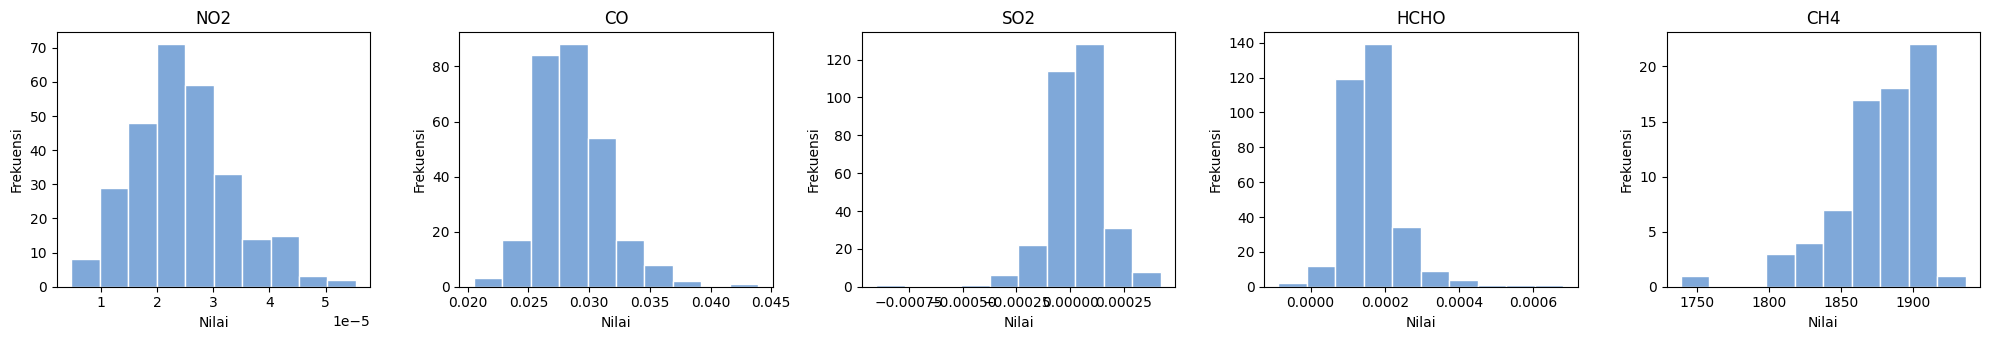

Frekuensi numpy.histogram: [np.int64(3), np.int64(17), np.int64(84), np.int64(88), np.int64(54), np.int64(17), np.int64(8), np.int64(2), np.int64(0), np.int64(1)]


In [44]:
# Verifikasi dengan numpy.histogram, lalu plot histogram untuk kelima kolom
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
kolom_list = ['no2', 'co', 'so2', 'hcho', 'ch4']

for ax, col in zip(axes, kolom_list):
    data_valid = df[col].dropna()
    ax.hist(data_valid, bins=10, color='#7fa8d9', edgecolor='white')
    ax.set_title(col.upper())
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('histogram_polutan_bangkalan.png', dpi=120)
plt.show()

# Cek angka bin numpy vs manual (kolom co)
freq_np, edges_np = np.histogram(df['co'].dropna(), bins=10)
print("Frekuensi numpy.histogram:", list(freq_np))


## 4. Menyusun Ulang Tabel Statistics Lengkap


In [45]:
kolom_list = ['no2', 'co', 'so2', 'hcho', 'ch4']
ringkasan = []

for col in kolom_list:
    s = df[col]
    s_valid = s.dropna()
    ringkasan.append({
        'Column'        : col,
        'Min'           : s_valid.min(),
        'Max'           : s_valid.max(),
        'Mean'          : s_valid.mean(),
        'Std deviation' : s_valid.std(ddof=1),
        'Variance'      : s_valid.var(ddof=1),
        'Skewness'      : s_valid.skew(),
        'Kurtosis'      : s_valid.kurt(),
        'Overall sum'   : s_valid.sum(),
        'No. missing'   : s.isna().sum(),
        'No. NaNs'      : np.isnan(s).sum(),
        'No. +inf'      : np.isposinf(s.fillna(0)).sum(),
        'No. -inf'      : np.isneginf(s.fillna(0)).sum(),
        'Median'        : s_valid.median(),
        'Row count'     : len(s),
    })

tabel_statistik = pd.DataFrame(ringkasan)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')
tabel_statistik


,Column,Min,Max,Mean,Std deviation,Variance,Skewness,Kurtosis,Overall sum,No. missing,No. NaNs,No. +inf,No. -inf,Median,Row count
0,no2,4.71696e-06,5.54211e-05,2.48246e-05,9.04359e-06,8.17864e-11,0.546036,0.385463,0.00700052,46,46,0,0,2.40767e-05,328
1,co,0.0204874,0.043943,0.0286525,0.0029402,8.64477e-06,0.867535,2.59907,7.85078,54,54,0,0,0.0283222,328
2,so2,-0.000902327,0.000421448,3.3773e-05,0.000129844,1.68596e-08,-1.3805,9.50849,0.0105034,17,17,0,0,3.29605e-05,328
3,hcho,-8.63589e-05,0.000680752,0.000165661,7.81111e-05,6.10134e-09,1.71807,8.0449,0.0533429,6,6,0,0,0.000157265,328
4,ch4,"1,739.1","1,936.17","1,875.53",32.8654,"1,080.13",-1.49841,3.28718,"136,913",255,255,0,0,"1,886.52",328


## 5. Kesimpulan

- Semua metrik pada Statistics Table KNIME berhasil direproduksi secara manual dan diverifikasi
  dengan `numpy`/`pandas`/`scipy`, dan hasilnya konsisten.
- Insight dari data polutan Bangkalan:
  - Kolom **`so2`** dan **`hcho`** punya **kurtosis tinggi** (9.508 dan 8.045) → distribusinya
    memiliki lebih banyak outlier/nilai ekstrem dibanding distribusi normal.
  - Kolom **`ch4`** punya **jumlah missing terbanyak** (255 dari 328 baris) → data metana paling
    jarang tersedia dibanding polutan lain.
  - Skewness positif pada `hcho` (1.718) dan `co` (0.868) menunjukkan distribusi condong ke kanan
    (ekor panjang di nilai besar), sedangkan `so2` (-1.38) dan `ch4` (-1.498) condong ke kiri.